In [1]:
import matplotlib.pyplot as plt
from nilearn.connectome import ConnectivityMeasure
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
from nilearn import signal
import pandas as pd

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'

# needs average GMs from sciencecloud
# (av-CM-GMs (generated on sciencecloud,npy-arrays, average-CorrelationMatrices-GradienMaps) )

In [2]:
# get labeling_noParcel for map_to_labels later
atlas = datasets.fetch_atlas_surf_destrieux() # len(atlas.map_left) = 10242 , as fsaverage5
regions = atlas['labels'].copy()
masked_regions = [b'Medial_wall', b'Unknown']
masked_labels = [regions.index(r) for r in masked_regions] # [42, 0]

labeling = np.concatenate([atlas['map_left'], atlas['map_right']]) # atlas['map_left'] == atlas.map_left -> array, each vertex has a label assignment (a number from 0-51)
mask = ~np.isin(labeling, masked_labels)
labeling_noParcel = np.arange(0,len(labeling),1,dtype = int)     # Map gradients to original parcels


In [3]:
[region for region in regions if b'post' in region]

[b'G_postcentral', b'Lat_Fis-post', b'S_collat_transv_post', b'S_postcentral']

In [4]:
#[region for region in regions if b'precentral' in region]
# table with regions and names: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2937159/

motor_mask = np.isin(labeling, atlas.labels.index(b'G_precentral')) # b'Pole_occipital, 'G_precentral
aud_mask = np.isin(labeling, atlas.labels.index(b'S_circular_insula_inf')) #
occ_mask = np.isin(labeling, atlas.labels.index(b'Pole_occipital'))

# check how many vertices are in mask: motor_mask.mean() * len(motor_mask)


In [25]:
# load in av-CM-GMs (generated on sciencecloud,npy-arrays, GradienMaps generated from average-CorrelationMatrices) 

gm = np.load('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/gm_av50_unfiltered.npy')
#gm = np.load('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/gm_av18_unfiltered_group-0.npy')
#gm = np.load('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/gm_av22_unfiltered_group-1.npy')

# hypothetical subject and sessions for later functions
subject = 'average_cmunfil_01'
ses=1 

# Map gradients to original standard space vectrors
grad = [None] * np.shape(gm)[1] # shape = (3, 18715)
for i, g in enumerate(gm.T):
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)


In [6]:
# align direction of gradients

if grad[0][motor_mask].mean() > 0: # motor region should be negative for grad 1
    grad[0] = -grad[0]

if grad[1][occ_mask].mean() < 0: # visual region should be positive for grad 2
    grad[1] = -grad[1]       

if grad[2][aud_mask].mean() > 0: # insula region should be negative for grad 3
    grad[2] = -grad[2]   



In [ ]:
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres

surf_lh, surf_rh = load_fsa5()

plot_hemispheres(surf_lh, surf_rh, array_name=grad, size=(1200, 400), cmap='viridis_r',
                 color_bar=True, label_text=['Grad1', 'Grad2', 'Grad3'], zoom=1.5)

In [10]:
# save them on as the "usual" grad1.npy file 
# those to fsaverag5.gii (
# transformation back currenlty only works on sciencecloud)

from utils import saveGradToNPFile, npFileTofs5Gii, fsav5Tofsav

saveGradToNPFile(grad, subject,ses, bids_folder=bids_folder)  

npFileTofs5Gii(subject,ses, bids_folder=bids_folder)

# fsav5Tofsav('average_cmunfil_01',1, bids_folder=bids_folder) # does not work on local, but on sciencecloud

In [2]:
from utils import loadGradAsNpArray

subject = 'average_cmunfil_01'
ses=1 

grad1, grad2 = loadGradAsNpArray(subject,ses,bids_folder,'', space='fsaverage5')


230429-13:34:54,506 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


<function matplotlib.pyplot.show(close=None, block=None)>

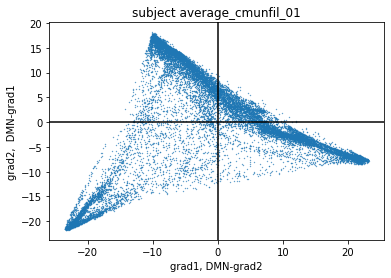

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.scatter(-grad1, -grad2, s=0.1, cmap = mpl.colormaps['cool']) # polarity f gradients is assigned arbitrary
plt.axvline(x=0, color = 'black')
plt.axhline(y=0, color = 'black')
plt.xlabel('grad1, DMN-grad2')
plt.ylabel('grad2,  DMN-grad1')
plt.title(f'subject {subject}')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

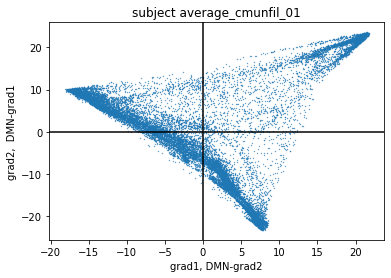

In [12]:
plt.scatter(grad2, grad1, s=0.1, cmap = mpl.colormaps['cool'])
plt.axvline(x=0, color = 'black')
plt.axhline(y=0, color = 'black')
#plt.xlabel('grad1, DMN-grad2')
#plt.ylabel('grad2,  DMN-grad1')
plt.title(f'subject {subject}')
plt.show

In [3]:
# gradient alignment
target_folder = op.join(bids_folder,'derivatives','correlation_matrices')
ses=1

cm_01 = np.load(op.join(target_folder,f'sub-01_ses-{ses}_corrMatrix_fsav5_unfiltered.npy'))
cm_02 = np.load(op.join(target_folder,f'sub-02_ses-{ses}_corrMatrix_fsav5_unfiltered.npy'))

In [4]:
gp = GradientMaps(kernel='normalized_angle', alignment='procrustes')

gp.fit([cm_01, cm_02]) # took 171m37s
np.save(op.join(target_folder,f'p-align_sub-1-2_fsav5_unfiltered.npy'),gp.gradients_) # shape (2, 18715, 10), 

GradientMaps(alignment='procrustes', kernel='normalized_angle')

In [ ]:
g_1 = gp.gradients_[1]
g_1 = g_1.reshape((np.shape(g_1)[1], np.shape(g_1)[0]))


In [27]:
gradients_unaligned = [None] * 2

for i in range(2):
    gradients_unaligned[i] = map_to_labels(gp.gradients_[i][:, 0], labeling,
                                           mask=mask, fill=np.nan)

In [30]:
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
surf_lh, surf_rh = load_fsa5()

label_text = ['Unaligned\sub 1', 'Unaligned\sub 2']
plot_hemispheres(surf_lh, surf_rh, array_name=gradients_unaligned, size=(1200, 400),
                 cmap='viridis_r', color_bar=True, label_text=label_text, zoom=1.5)

In [23]:
np.shape(g_1.reshape((np.shape(g_1)[1], np.shape(g_1)[0])))

(10, 18715)

In [32]:
# With procrustes alignment
gradients_procrustes = [None] * 2
for i in range(2):
    gradients_procrustes[i] = map_to_labels(gp.aligned_[i][:, 0], labeling, mask=mask,
                                            fill=np.nan)

label_text = ['Procrustes\nGroup 1', 'Procrustes\nGroup 2']
plot_hemispheres(surf_lh, surf_rh, array_name=gradients_procrustes, size=(1200, 400),
                 cmap='viridis_r', color_bar=True, label_text=label_text, zoom=1.5)

In [4]:
g_ref = np.load('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/gm_av50_unfiltered.npy')

g_align_sub1 = GradientMaps(kernel='normalized_angle', n_components=3,approach='le', alignment='procrustes')
g_align_sub1.fit(cm_01,reference=g_ref) # took 64 m

np.save(op.join(target_folder,f'sub-1_ref-p-align_fsav5_unfiltered.npy'),g_align_sub1.gradients_) # shape (18715, 10), 

GradientMaps(alignment='procrustes', approach='le', kernel='normalized_angle',
             n_components=3)

In [39]:
# filter connectivity matrix first
from scipy.sparse.csgraph import connected_components


cc = connected_components(cm_01)
mask_cc = cc[1] == 0 # all nodes in 0 belong to the largest connected component, check #-components in cc[0]

cm = cm_01.copy() # (18715, 18715)
cm[np.ix_(np.invert(mask_cc), np.invert(mask_cc))] = 0

# enough to set edges of disconnected nodes to 0 (makes it easier for remapping later etc.) or does it need a reestimation of a connectivity matrix with the nodes removed here?

In [58]:
mask_a_cc = mask.copy() # np.shape(mask[mask==True]) = 18715

mask_a_cc[mask_a_cc == True] = mask_cc

cm = cm_01[np.ix_(mask_cc, mask_cc)]

g_ref_fil = g_ref[mask_cc]

In [59]:
g_align_sub1_fil = GradientMaps(kernel='normalized_angle', n_components=3,approach='le', alignment='procrustes')
g_align_sub1_fil.fit(cm,reference=g_ref_fil) 

# took 106, then
# --> ValueError: Affinity matrix contains NaN or Inf values. Common causes of this include NaNs/Infs or rows of zeros in the input matrix.

np.save(op.join(target_folder,f'sub-1_ref-p-align_fsav5_filtered.npy'),g_align_sub1_fil.gradients_) # shape (2, 18715, 10), 

: 

: 

In [37]:
gm = g_align_sub1.gradients_

grad = [None] * np.shape(gm)[1] # shape = (3, 18715)
for i, g in enumerate(gm.T):
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)


In [28]:
gm_av = gm
grad_av = grad

In [38]:
plot_hemispheres(surf_lh, surf_rh, array_name=grad, size=(1200, 400), cmap='viridis_r',
                 color_bar=True, label_text=['Grad1', 'Grad2','Grad3'], zoom=1.5)